In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-5.4')

small_llm = ChatOpenAI(model='gpt-5.4-mini')

In [3]:
# from langchain_openai import AzureChatOpenAI

# llm = AzureChatOpenAI(
#     azure_deployment='gpt-4o-2024-11-20',
#     api_version='2024-08-01-preview',   
# )

# small_llm = AzureChatOpenAI(
#     azure_deployment='gpt-4o-mini-2024-07-18',
#     api_version='2024-08-01-preview',
# )

In [4]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()


In [6]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

C:\Users\cleft\AppData\Local\Temp\ipykernel_10480\3256258543.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\cleft\AppData\Local\Temp\ipykernel_10480\3256258543.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [7]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001FDF5878110>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001FDF5878110>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001FDF5878110>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001FDF5878110>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x000001FDF5878110>)]

In [8]:
# from langchain.agents import load_tools

# tools = load_tools(
#     ["arxiv"],
# )
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

arxiv = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

loaded_tool_list = [arxiv]

In [9]:
loaded_tool_list


[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=3, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=4000))]

In [10]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.tools.retriever import create_retriever_tool


embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
        collection_name="real_estate_tax",
        persist_directory="./real_estate_tax_collection",
        embedding_function=embeddings
    )

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to April 2026'
)


In [11]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list +loaded_tool_list
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [12]:
# multiply.invoke({'a': 3, 'b': 5})

In [13]:
# from langchain_core.messages import HumanMessage

# ai_message = llm_with_tools.invoke('3에다 5를 더하면?')

In [14]:
# ai_message

In [15]:
# tool_node.invoke({'messages': [ai_message]})

In [16]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [17]:
from langchain_core.messages import SystemMessage


def agent(state: AgentState) -> AgentState:
    messages = state['messages']
    print(f'messages length == {len(messages)}')
    summary = state['summary']
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
        
    print(f'agent_messages_with_summary == {messages}')    
    response = llm_with_tools.invoke(messages)
    # print(f"agent messages == {response} ")
    
    return {'messages': [response]}

In [18]:
from typing import Literal
from langgraph.types import Command, interrupt


def human_review(state: AgentState) -> Command[Literal['tools']]:
    messages = state['messages']
    last_message = messages[-1]
    tool_call = last_message.tool_calls[-1]
    human_review = interrupt({
        'question': '이렇게 진행하면 될까?',
        'tool_call': tool_call
    })
    review_action = human_review['action']
    review_data = human_review.get('data', None)

    if review_action == 'continue':
        return Command(goto='tools')

    if review_action == 'update_args':
        updated_ai_message = {
            'id': last_message.id,
            'role': 'ai',
            'content': last_message.content,
            'tool_calls': [{
                'id': tool_call['id'],
                'name': tool_call['name'],
                'args': review_data
            }],
        }
        return Command(goto='tools', update={'messages': [updated_ai_message]})



In [19]:
def summarize_messages(state: AgentState):
    messages = state['messages']
    summary = state['summary']
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
        chat_history: {messages}
        summary: {summary}'''

    summary = small_llm.invoke(summary_prompt)
    print(f'summary == {summary}')
    # response = llm_with_tools.invoke(messages)
    return {'summary': summary.content}

In [20]:
from langchain_core.messages import RemoveMessage


def delete_message(state: AgentState):
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [21]:
from typing import Literal
# from langgraph.graph import END

def should_continue(state: AgentState) -> Literal['tools', 'delete_message']:
    messages = state['messages']

    print(f"should_continue messages == {messages} ")
    
    last_ai_message = messages[-1]
    
    if last_ai_message.tool_calls:
        return 'human_review'

    return 'summarize_messages'

In [22]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node('human_review', human_review)
graph_builder.add_node('delete_message', delete_message)
graph_builder.add_node('summarize_messages', summarize_messages)

In [23]:
from langgraph.graph import START, END
# from langgraph.prebuilt import tools_condition

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['human_review', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_message')
graph_builder.add_edge('delete_message', END)

In [24]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
graph= graph_builder.compile(
    checkpointer=checkpointer
)

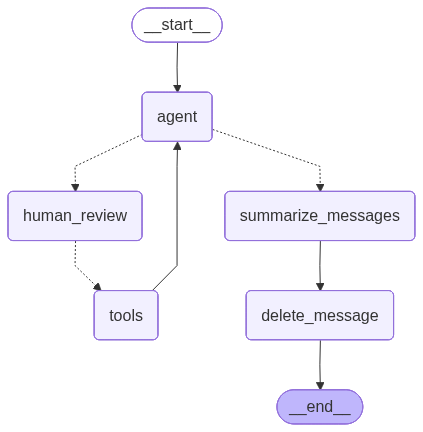

In [25]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'paper_summary'
    }
}

# query = 'what currency is in Billy Giles\' birthplace? Find the currency and email it to cleftin02@gamil.com'
# query = 'Attention is All You Need라는 논문을 요약해서 cleftin02@gamil.com으로 메일 보낼 겁니다. 우선 이메일 보낼낼 초안을 작성해 주세요'
query = '15억 일 때 종합부동산세를 계산해 줄 수 있나요?'

for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

15억 일 때 종합부동산세를 계산해 줄 수 있나요?
messages length == 1
agent_messages_with_summary == [HumanMessage(content='15억 일 때 종합부동산세를 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='23aec7a2-dcf8-4a50-a488-56502e8083ed')]
should_continue messages == [HumanMessage(content='15억 일 때 종합부동산세를 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='23aec7a2-dcf8-4a50-a488-56502e8083ed'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 843, 'total_tokens': 901, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXh8VrQj8UCrzCz4p480C6Zihj3xe', 'service_tier': '

In [27]:
# current_message_list = graph.get_state(config).values['messages']
# current_message_list

In [28]:
graph.get_state(config).values['messages']

[HumanMessage(content='15억 일 때 종합부동산세를 계산해 줄 수 있나요?', additional_kwargs={}, response_metadata={}, id='23aec7a2-dcf8-4a50-a488-56502e8083ed'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 843, 'total_tokens': 901, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DXh8VrQj8UCrzCz4p480C6Zihj3xe', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019db8dd-651c-70a3-83e9-1348e31124c5-0', tool_calls=[{'name': 'real_estate_tax_retriever', 'args': {'query': '2026년 15억원 주택 종합부동산세 계산 방법 공정시장가액비율 기본공제 세율 1주택자 다주택자'}, 'id': 'call_77H3Q9DbzSkITvkkLTpqCig4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_me

In [29]:
graph.get_state(config).next

('human_review',)

In [30]:
# for chunk in graph.stream(
#     Command(resume={'action': 'continue'}),
#     config=config,
#     stream_mode='updates'
# ):
#     print(chunk)

In [ ]:
# for chunk in graph.stream(
#     Command(resume={'action': 'update_args', 'data': {'query': '51세 일반인 15억 주택 1채소유 시 종합부동산세 얼마입니까?'}}),
#     config=config,
#     stream_mode='updates'
# ):
#     print(chunk)

{'human_review': {'messages': [{'id': 'lc_run--019db8dd-651c-70a3-83e9-1348e31124c5-0', 'role': 'ai', 'content': '', 'tool_calls': [{'id': 'call_77H3Q9DbzSkITvkkLTpqCig4', 'name': 'real_estate_tax_retriever', 'args': {'query': '51세 일반인 15억 주택 1채소유 시 종합부동산세 얼마입니까?'}}]}]}}
{'tools': {'messages': [ToolMessage(content='법제처 법제처 2 국가법령정보센터\n종합부동산세법\n지역에 소재하는 1주택의 경우에는 2009년 1월 1일부터 2011년 12월 31일까지의 기간 중 납세의무자가 성립하는 분에 한정한다. ③제3항의 규정에 따른 주택을 보유한 납세의무자는 해당 연도 9월 16일부터 9월 30일까지 대통령령으로 정하는 바에 따라 관할 세무서장(이하 “관할세무서장”이라 한다)에게 해당 주택의 보유현황을 신고하여야 한다. <신설 2007. 1. 11., 2020. 6. 9.>\n④ 제1항을 적용할 때 다음 각 호의 어느 하나에 해당하는 경우에는 1세대 1주택자로 본다. <개정 2022. 9. 15.>\n  1. 1주택(주택의 부속토지만을 소유한 경우는 제외한다)과 다른 주택의 부속토지(주택의 건물과 부속토지의 소유자가 다른 경우의 그 부속토지로 한정한다)를 합계하여 소유하고 있는 경우\n  2. 1세대 1주택자가 1주택을 양도하기 전에 다른 주택을 대체취득하여 일시적으로 2주택이 된 경우로서 대통령령으로 정하는 경우\n  3. 1주택과 상속받은 주택으로서 대통령령으로 정하는 주택(이하 “상속주택”이라 한다)을 합계 소유하고 있는 경우\n  4. 1주택과 주택 소재 지역, 주택 가격 등을 고려하여 대통령령으로 정하는 지방 저가주택(이하 “지방 저가주택”이라 한다)을 함께 소유하고 있는 경우\n⑤ 제4항제2호부터 제4호까지의 규정

In [ ]:
# graph.get_state(config).values['messages']

[AIMessage(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019db8dd-651c-70a3-83e9-1348e31124c5-0', tool_calls=[{'name': 'real_estate_tax_retriever', 'args': {'query': '51세 일반인 15억 주택 1채소유 시 종합부동산세 얼마입니까?'}, 'id': 'call_77H3Q9DbzSkITvkkLTpqCig4', 'type': 'tool_call'}], invalid_tool_calls=[]),
 ToolMessage(content='법제처 법제처 2 국가법령정보센터\n종합부동산세법\n지역에 소재하는 1주택의 경우에는 2009년 1월 1일부터 2011년 12월 31일까지의 기간 중 납세의무자가 성립하는 분에 한정한다. ③제3항의 규정에 따른 주택을 보유한 납세의무자는 해당 연도 9월 16일부터 9월 30일까지 대통령령으로 정하는 바에 따라 관할 세무서장(이하 “관할세무서장”이라 한다)에게 해당 주택의 보유현황을 신고하여야 한다. <신설 2007. 1. 11., 2020. 6. 9.>\n④ 제1항을 적용할 때 다음 각 호의 어느 하나에 해당하는 경우에는 1세대 1주택자로 본다. <개정 2022. 9. 15.>\n  1. 1주택(주택의 부속토지만을 소유한 경우는 제외한다)과 다른 주택의 부속토지(주택의 건물과 부속토지의 소유자가 다른 경우의 그 부속토지로 한정한다)를 합계하여 소유하고 있는 경우\n  2. 1세대 1주택자가 1주택을 양도하기 전에 다른 주택을 대체취득하여 일시적으로 2주택이 된 경우로서 대통령령으로 정하는 경우\n  3. 1주택과 상속받은 주택으로서 대통령령으로 정하는 주택(이하 “상속주택”이라 한다)을 합계 소유하고 있는 경우\n  4. 1주택과 주택 소재 지역, 주택 가격 등을 고려하여 대통령령으로 정하는 지방 저가주택(이하 “지방 저가주택”이라 한다)을 함께 소유하고 있는 경우\n⑤